In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# initialize distribution

- This is mixture of gaussian
- each gaussian is 2d

In [180]:
mus = np.array([[-2, -2], [2, 2]])
sigs = np.array([[0.5, 0.5], [0.5, 0.5]])
pi = np.array([0.4, 0.6])

def sample(N):
    """
    get N sample from a mixture of 2d gaussians.
    There are two 2d gaussian defined by mus, sigs, pi.
    Note that we assume the two dimension are independent, so the covariance matrix is diagonal.
    I give the diagonal values in sigs, so sigs shape is [2, 2]
    """
    if N < 0:
        raise ValueError("N must be non-negative")

    component_ids = np.random.choice(len(pi), size=N, p=pi)
    return np.random.normal(loc=mus[component_ids], scale=np.sqrt(sigs[component_ids]))

# Draw PDF and Sample

(<Figure size 640x480 with 1 Axes>, <Axes: >)

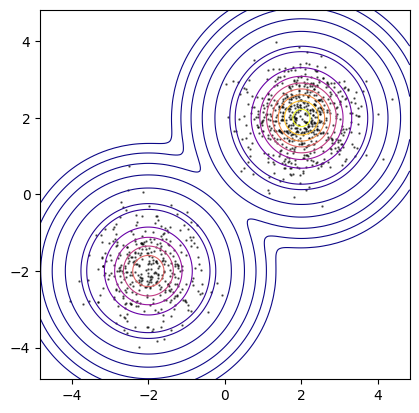

In [181]:
def plot_pdf():
    """
    plot the pdf of this mixture of 2d gaussians distribution.
    This should be a 2d plot, x is the first dimension, y is the second dimension.
    I want to show the contour line. The contour line should be the level set of the pdf.
    """

    grid_size = 200
    padding = 4.0
    stds = np.sqrt(sigs)
    lower = np.min(mus - padding * stds, axis=0)
    upper = np.max(mus + padding * stds, axis=0)

    x = np.linspace(lower[0], upper[0], grid_size)
    y = np.linspace(lower[1], upper[1], grid_size)
    xx, yy = np.meshgrid(x, y)
    points = np.stack([xx, yy], axis=-1)

    density = np.zeros(xx.shape)
    for weight, mean, var in zip(pi, mus, sigs):
        diff = points - mean
        norm = 1.0 / (2.0 * np.pi * np.sqrt(np.prod(var)))
        exponent = -0.5 * np.sum(diff ** 2 / var, axis=-1)
        density += weight * norm * np.exp(exponent)

    fig, ax = plt.subplots(dpi=100)
    low_levels = np.geomspace(density.max() * 1e-5, density.max() * 0.03, 6)
    high_levels = np.linspace(density.max() * 0.05, density.max() * 0.95, 8)
    levels = np.concatenate([low_levels, high_levels])
    contour = ax.contour(xx, yy, density, levels=levels, cmap="plasma", linewidths=0.8)
    ax.set_aspect("equal", adjustable="box")
    return fig, ax

def plot_samples(N):
    """
    sample N points from this mixture of 2d gaussians distribution,
    and plot them as scatters on top of the pdf contour figure.
    """
    fig, ax = plot_pdf()
    samples = sample(N)
    ax.scatter(samples[:, 0], samples[:, 1], s=0.5, c="black", alpha=0.6)
    return fig, ax

# We sample 1000 points
plot_samples(1000)

# What we want?
- sample from a easy distribution
- do some transformation so that the sample follow the target distribution

# Diffusion Process

We first define how a sample in target distribution transform to a sample in a easy distribution, so-called forward process

<img src="assets/forward_backward.png" width="800px">

## Forward Formulation

$$
q(x_t \mid x_{t-1}) := \mathcal{N}\left(x_t;\ \sqrt{1 - \beta_t}\, x_{t-1},\ \beta_t I \right)
$$

This definition seems simple, but it is actually delicate:
- It ensures $x_T \sim \mathcal{N}(0, 1)$
- It limits  the marginal distributon $\mathrm{Var}(x_t)$.

In [182]:
# let's define a variance schedule

T = 500
def build_variance_schedule(T):
    betas = np.zeros(T+1)
    betas[1:] = np.linspace(1e-3, 0.02, T)
    return betas

betas = build_variance_schedule(T)

# closed-form forward

Given $x_0$, $x_t$ follows:
$$
q(x_t \mid x_0) := \mathcal{N}\big(x_t;\ \sqrt{\bar{\alpha}_t}\,x_0,\ (1-\bar{\alpha}_t)I\big)
$$

$$
x_t := \sqrt{\bar{\alpha}_t}\,x_0 + \sqrt{1 - \bar{\alpha}_t}\,\epsilon_t
$$

Where $\alpha_t = 1 - \beta_t$, and $\bar{\alpha}_t := \prod_{i=1}^{t} \alpha_i$

In [184]:
# let's prepare alphas and alphas_bar
def build_alpha(betas):
    """
    Return alphas and alphas_bar
    """
    alphas = 1 - betas
    alphas_bar = np.cumprod(alphas)
    return alphas, alphas_bar

alphas, alphas_bar = build_alpha(betas)

## compute the sample give $x_0$, $t$ and a noise from normal distribution

In [185]:
def q_sample(x_0, t, eps):
    """
    Sample from the q distribution.
    x_0: [N, 2]
    t: [N] range from [1, 500]
    eps: [N, 2]
    """
    return torch.sqrt(alphas_bar[t]) * x_0 + torch.sqrt((1 - alphas_bar[t])) * eps

# Reverse process

To recovery a noise to image, we need to estimate the reverse distribution:
$$
q(x_t \mid x_{t+1}) = \frac{q(x_{t+1} \mid x_t)\, q(x_t)}{q(x_{t+1})}
$$

But this is intractable because we cannot get $q(x_{t})$:

$$
q(x_t)
= \int_{x_{t-1},\ldots,x_0} q(x_t, x_{t-1}, \ldots, x_0)\, dx_{t-1}\cdots dx_0
= \int_{x_{t-1},\ldots,x_0} q(x_0)\prod_{i=1}^{t} q(x_i \mid x_{i-1})\, dx_{t-1}\cdots dx_0
$$

To solve this, we try to approximate it with functions parameterized by $\theta$

$$
p_\theta(x_{0:T}) = p_\theta(x_T)\prod_{t=1}^{T} p_\theta(x_{t-1} \mid x_t)
$$

... a lot of math

# Optimization Objective 

to this end, it turns out that we only need to optimize this:

$$
\mathcal{L}_t := \mathbb{E}_{\epsilon_t, x_0}\Big[\left\|\epsilon_t - \epsilon_\theta(x_t(x_0,\epsilon_t), t)\right\|^2\Big]
$$

# build the model

In [59]:
import torch
import torch.nn as nn

In [186]:
t_emb_dim = 16

class Toyfusion(nn.Module):
    def __init__(self):
        super().__init__()
        self.data_layers = nn.Sequential(nn.Linear(2, 16), nn.Tanh(), nn.Linear(16, 32))
        self.timestep_layer = nn.Linear(t_emb_dim, 32)
        self.output_layers = nn.Sequential(
            nn.Tanh(), nn.Linear(32, 16),
            nn.Tanh(), nn.Linear(16, 8),
            nn.Tanh(), nn.Linear(8, 2)
        )

    def forward(self, x_t, t):
        t_emb = self._get_timestep_embedding(t)
        h = self.data_layers(x_t) + self.timestep_layer(t_emb)
        return self.output_layers(h)

    def _get_timestep_embedding(self, t):
        if not torch.is_tensor(t):
            t = torch.tensor(t)
        
        t = t.float().reshape(-1, 1)
        half_dim = t_emb_dim // 2
        frequencies = torch.exp(
            -np.log(10000) * torch.arange(half_dim, device=t.device, dtype=t.dtype) / half_dim
        )
        angles = t * frequencies.reshape(1, -1)
        return torch.cat([torch.sin(angles), torch.cos(angles)], dim=-1)

## Training

In [187]:
# make some variable to tensor
betas = torch.from_numpy(betas).float().view(-1, 1) # [T+1, 1]
alphas = torch.from_numpy(alphas).float().view(-1, 1) # [T+1, 1]
alphas_bar = torch.from_numpy(alphas_bar).float().view(-1, 1) # [T+1, 1]

In [188]:
model = Toyfusion()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

In [189]:
max_steps = 100000
batch_size = 1024

for step in range(max_steps):
    x0 = torch.from_numpy(sample(batch_size)).float()
    noise = torch.randn_like(x0)
    t = torch.randint(low=1, high=T+1, size=(batch_size,))
    xt = q_sample(x0, t, noise)
    noise_pred = model(xt, t)
    loss = torch.nn.functional.mse_loss(noise, noise_pred)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if step % 10000 == 0 or step == max_steps - 1:
        print(f"step={step}, loss={loss.item():.4f}")

step=0, loss=1.0474
step=10000, loss=0.3651
step=20000, loss=0.3272
step=30000, loss=0.3578
step=40000, loss=0.3532
step=50000, loss=0.3724
step=60000, loss=0.3464
step=70000, loss=0.3750
step=80000, loss=0.4063
step=90000, loss=0.3669
step=99999, loss=0.3734


# Sampling

remember we parameterize our model by:

$$
p_\theta(x_{t-1} \mid x_t) := \mathcal{N}\big(x_{t-1}; \mu_\theta(x_t, t), \sigma_t^2 I\big)
$$

More specifically:

$$
\mu_\theta\big(x_t(x_0,\epsilon_t), t\big)
:= \frac{1}{\sqrt{\alpha_t}}
\left(
x_t(x_0,\epsilon_t)
-
\frac{\beta_t}{\sqrt{1-\bar{\alpha}_t}}
\epsilon_\theta\big(x_t(x_0,\epsilon_t), t\big)
\right)
$$


In [190]:
def p_sample(xt, t, noise_pred):
    return 1.0 / torch.sqrt(alphas[t]) * (xt - betas[t] / torch.sqrt((1 - alphas_bar[t])) * noise_pred )

In [191]:
# let's try to denoise some noise,
# first we sample x_t

model.eval()

@torch.no_grad()
def sample_ddpm(N=1000):
    xt = torch.randn((N, 2))
    for i in range(T, 0, -1):
        # compute for x_{t-1}
        t = torch.tensor([i]).repeat(N)
        noise_pred = model(xt, t)
        mu = p_sample(xt, t, noise_pred)
        xt = mu + torch.sqrt(betas[t]) * torch.randn_like(xt) if i != 1 else mu
    return xt

xt = sample_ddpm()

In [192]:
def plot_points(points, with_pdf=True):
    """
    Plot existing 2d points.
    points: [N, 2] numpy array or torch tensor.
    """
    if torch.is_tensor(points):
        points = points.detach().cpu().numpy()

    if with_pdf:
        fig, ax = plot_pdf()
    else:
        fig, ax = plt.subplots()
        ax.set_aspect("equal", adjustable="box")

    ax.scatter(points[:, 0], points[:, 1], s=0.5, c="black", alpha=0.6)
    return fig, ax

(<Figure size 640x480 with 1 Axes>, <Axes: >)

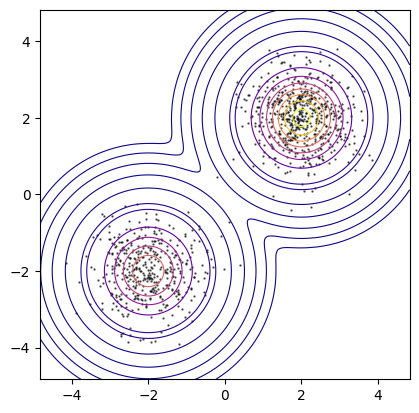

In [193]:
plot_points(xt)

# Save as gif 

In [194]:
import imageio.v2 as imageio
from pathlib import Path

@torch.no_grad()
def sample_ddpm_gif(N=1000, save_every=2, frame_dir="frames", gif_path="sampling.gif"):
  model.eval()

  frame_dir = Path(frame_dir)
  frame_dir.mkdir(exist_ok=True)

  frame_paths = []
  xt = torch.randn((N, 2))

  for i in range(T, 0, -1):
      t = torch.full((N,), i, dtype=torch.long)
      noise_pred = model(xt, t)
      mu = p_sample(xt, t, noise_pred)
      xt = mu + torch.sqrt(betas[t]) * torch.randn_like(xt) if i != 1 else mu

      if i % save_every == 0 or i == 1:
          fig, ax = plot_points(xt)
          ax.set_title(f"t = {i}")
          ax.set_xlim(-4.5, 4.5)
          ax.set_ylim(-4.5, 4.5)

          frame_path = frame_dir / f"step_{i:04d}.png"
          fig.savefig(frame_path, dpi=120)
          plt.close(fig)

          frame_paths.append(frame_path)

  images = [imageio.imread(path) for path in frame_paths]
  imageio.mimsave(gif_path, images, duration=5)

  return xt

xt = sample_ddpm_gif(N=1000, save_every=5, gif_path="sampling.gif")

![](sampling.gif)

# Reference
- https://mbernste.github.io/posts/diffusion_part1/
- https://mbernste.github.io/posts/diffusion_part2/
- https://lilianweng.github.io/posts/2021-07-11-diffusion-models/

SyntaxError: invalid syntax (3182438915.py, line 1)